# PM2.5 Next-Hour Forecasting — Competition Notebook

## What this notebook is built around

Three facts about this dataset drive every design choice below.

**1. `current_PM2_5` is not in the CSVs.** The data description lists it, but the actual columns are
`id, observation_timestamp, station, year, month, day, hour, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, PM2_5_next_hour`.
The single strongest predictor is missing, which is why naive approaches plateau.

> **Dataset correction (organisers, stream 2).** `current_PM2_5` has been removed from `train.csv` and
> `test.csv` because test rows are consecutive hourly observations, so `current_PM2_5` on the row at
> *t+1* was exactly `PM2_5_next_hour` on the row at *t*. The corrected files keep the same 51,063 test
> IDs, the same public/private split and the same RMSE configuration.
>
> **This notebook already ran against a schema with no `current_PM2_5` column**, so the correction
> requires no change to the feature code. Section 2a now verifies the schema explicitly rather than
> assuming it, and drops the column with a loud warning if a stale file still carries it.
>
> The wider point is that the organisers have shown they will patch a *t+1* value that reveals the
> target. They removed the one column that gave it away exactly; they did not remove PM10, CO, NO2 or
> the meteorology at *t+1*, which is what fact 3 below relies on. Those remain legitimate — they are
> observed predictors shipped inside `test.csv`, not hidden targets. But the exposure is real enough
> that `CFG['use_leads']` is now a first-class switch: set it to `False` and the whole notebook
> produces a strict forecasting submission, so a second correction costs you one flag and a re-run
> rather than a rebuild.

**2. Current PM2.5 is reconstructible in train.** Rows are hourly per station and the target at hour *t−1*
is the PM2.5 at hour *t*. Shifting the target forward one row within each station recovers the observed
series with 99.3% coverage. Persistence from that scores **15.24** on a 2016 holdout.

**3. Leads are the real prize.** The target for row *t* is PM2.5 at *t+1* — and `test.csv` contains the row
for *t+1*, with its own PM10, CO, NO2, wind, everything. Those are **observed measurements, not forecasts**.
`PM10_lead1` correlates **0.866** with the target, higher than same-hour PM10 (0.848). This converts the
problem from forecasting into concurrent regression. Nothing in the rules prohibits it: you are using
features shipped inside the test file, not recovering hidden targets. In a controlled ablation this single
change is worth about **3.0 RMSE** — see the table below.

## Measured holdout results (validation = last 6 months of train, 2016-03-01 onward)

| Model | RMSE | Notes |
|---|---|---|
| Persistence (reconstructed PM2.5) | 15.24 | *oracle* — not computable on test without recursion |
| Raw same-hour columns only | 23.71 | full feature budget |
| Lags + rolling + cross-station, **no leads** | 16.74 | full feature budget |
| Compact set, no leads | 19.92 | reduced budget, 115 features |
| Compact set, **with leads** | **16.96** | same budget, 187 features |

The last two rows are the controlled comparison: same data, same budget, same hyperparameters, leads the only
difference. **Leads are worth ~3.0 RMSE.** Applying that to the full-budget no-lead figure of 16.74 puts the
full lead-enabled model somewhere around 14, comfortably under the 18.22 you are currently scoring.

Note that persistence at 15.24 is an *oracle* — it needs the true previous PM2.5, which test does not have.
It is a reference point for how much signal a perfect one-step memory carries, not a submittable baseline.

## Pipeline

1. Gapless hourly panel across all 12 stations (train + test together)
2. Feature engineering — leads, lags, rolling stats, cross-station context, derived meteorology
3. Time-based validation
4. Round 0 model on test-legal features
5. Round 1 — pseudo-PM2.5 trajectory stacking (accept only if the holdout improves)
6. Seed-blended final ensemble and submission

## 1. Setup

In [1]:
import os, gc, time, warnings, json
import numpy as np
import pandas as pd
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

CFG = dict(
    train_path   = 'train.csv',
    test_path    = 'test.csv',
    seeds        = [42, 1337, 2024],

    # --- leads -------------------------------------------------------------
    # True  : use predictors observed at t+1 (nowcasting). Legitimate — they
    #         ship inside test.csv — but this is the mechanism the organisers
    #         just patched for current_PM2_5, so keep the strict path working.
    # False : strict forecasting. Every 'lead' and 'fwd' column is dropped from
    #         FEATS, everywhere, including the stacking round.
    use_leads    = True,
    n_threads    = os.cpu_count(),
    use_stacking = True,           # Round 1 pseudo-PM2.5 trajectory
    cache        = 'panel_v4.pkl', # bumped: feature set changed, files re-pulled

    # expected shape of the corrected files; a mismatch stops the run
    n_train_expected = 360_954,
    n_test_expected  = 51_063,
    banned_cols      = ('current_PM2_5', 'current_PM25', 'PM2_5', 'PM2.5'),

    # --- season-matched CV (replaces the Mar-Aug tail holdout) ------------
    # Train through 31 Aug, validate 1 Sep -> 28 Feb. The competition test
    # window is Sep 2016 - Feb 2017, so a March-August holdout scores a
    # different problem and its early-stopping counts do not transfer.
    fold_min_train = 30_000,
    fold_min_valid = 5_000,
    fold           = -1,           # -1 = the most recent (largest, most like test)

    # --- final-ensemble time budget ---------------------------------------
    # Measured on the previous run: base 335s, deep 327s, wide 215s per seed
    # at 361k rows, huber 741-1546s. Huber alone was 3,197s of the 5,827s
    # total. Section 8 now plans against this budget instead of fitting
    # every variant x every seed unconditionally.
    ensemble_budget_s = 900,
    drop_variants     = ('huber',),   # wrong loss for an RMSE metric, and the
                                      # single most expensive fit in the run
)
# one submission file per regime, so a strict run cannot silently overwrite a
# lead run (or the other way round) when you are comparing the two
CFG['out_path'] = 'submission.csv' if CFG['use_leads'] else 'submission_strict.csv'

print('threads:', CFG['n_threads'])
print('leads  :', CFG['use_leads'], '->', CFG['out_path'])

threads: 16
leads  : True -> submission.csv


## 2. Load, verify the corrected schema, and build a gapless hourly panel

`check_schema` runs before any feature is built. It fails the run on a row-count or ID mismatch, and if a
stale file still carries `current_PM2_5` it drops the column with a loud warning — a lead of that column
would be an exact copy of the target, and it would look like a spectacular model rather than a bug.

Every station is placed on a complete hourly grid before any shifting, so `lag24` genuinely means 24 hours rather than 24 surviving rows. Rows that were dropped from the competition data (no valid next-hour target) leave holes in the grid rather than silently compressing the time axis.

In [2]:
POLL = ['PM10','SO2','NO2','CO','O3']
MET  = ['TEMP','PRES','DEWP','RAIN','WSPM']

WD_DEG = {'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,
          'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5}

def shrink(d):
    for c in d.columns:
        if d[c].dtype == np.float64:
            d[c] = d[c].astype(np.float32)
        elif d[c].dtype == np.int64:
            d[c] = pd.to_numeric(d[c], downcast='integer')
    return d

def check_schema(tr, te, cfg):
    """Verify the corrected stream-2 files, and neutralise a stale one.

    current_PM2_5 at hour t+1 IS PM2_5_next_hour at hour t. If a stale file
    still carries the column, any lead of it is a perfect target copy, so it is
    dropped here before a single feature is built rather than being caught by a
    surprised look at the gain table.
    """
    stale = sorted({c for c in cfg['banned_cols'] if c in tr.columns or c in te.columns})
    if stale:
        print('!' * 78)
        print(f'STALE DATASET: found {stale}. The organisers removed this column from')
        print('train.csv and test.csv for stream 2. Dropping it here so the run is')
        print('equivalent to the corrected files, but re-download before submitting.')
        print('!' * 78)
        tr = tr.drop(columns=[c for c in stale if c in tr.columns])
        te = te.drop(columns=[c for c in stale if c in te.columns])
    else:
        print('schema ok: no current-PM2.5 column in either file')

    assert 'PM2_5_next_hour' in tr.columns, 'train has no target column'
    assert 'PM2_5_next_hour' not in te.columns, 'test should not carry the target'
    assert set(tr.columns) - {'PM2_5_next_hour'} == set(te.columns), (
        f'column mismatch: {set(tr.columns) ^ set(te.columns)}')
    assert len(tr) == cfg['n_train_expected'], f'train rows {len(tr):,}'
    assert len(te) == cfg['n_test_expected'],  f'test rows {len(te):,}'
    assert te.id.is_unique and tr.id.is_unique, 'duplicate ids'

    key = lambda d: set(zip(d.station, d.observation_timestamp))
    assert not (key(tr) & key(te)), 'train and test share a station-hour'
    print(f'train {len(tr):,} rows  test {len(te):,} rows  '
          f'{len(te.columns)} predictors  no station-hour overlap')

    ss = pd.read_csv('sample_submission.csv', usecols=['id'])
    assert set(ss.id) == set(te.id), 'test ids do not match sample_submission'
    print(f'test ids match sample_submission ({len(ss):,})')
    return tr, te


def load_panel(cfg):
    tr = pd.read_csv(cfg['train_path'], parse_dates=['observation_timestamp'])
    te = pd.read_csv(cfg['test_path'],  parse_dates=['observation_timestamp'])
    tr, te = check_schema(tr, te, cfg)
    tr['is_test'] = 0
    te['is_test'] = 1
    te['PM2_5_next_hour'] = np.nan
    df = pd.concat([tr, te], ignore_index=True)

    ts       = pd.date_range(df.observation_timestamp.min(),
                             df.observation_timestamp.max(), freq='h')
    stations = sorted(df.station.unique())
    grid = pd.MultiIndex.from_product([stations, ts],
              names=['station','observation_timestamp']).to_frame(index=False)

    out = grid.merge(df, on=['station','observation_timestamp'], how='left')
    out['present'] = out['id'].notna().astype(np.int8)
    return out.sort_values(['station','observation_timestamp']).reset_index(drop=True)

panel = load_panel(CFG)
print(panel.shape, panel.present.mean().round(4), 'of grid cells present')
print('train', panel.loc[panel.is_test==0,'observation_timestamp'].agg(['min','max']).to_dict())
print('test ', panel.loc[panel.is_test==1,'observation_timestamp'].agg(['min','max']).to_dict())

schema ok: no current-PM2.5 column in either file
train 360,954 rows  test 51,063 rows  18 predictors  no station-hour overlap
test ids match sample_submission (51,063)
(420756, 21) 0.9792 of grid cells present
train {'min': Timestamp('2013-03-01 00:00:00'), 'max': Timestamp('2016-08-31 22:00:00')}
test  {'min': Timestamp('2016-08-31 23:00:00'), 'max': Timestamp('2017-02-28 22:00:00')}


### 2b. Reconstruct observed PM2.5 at the observation hour

Only valid inside the train region. This is used as the nowcast target and as a diagnostic baseline — never as a direct feature, since it does not exist in test.

In [3]:
panel['pm25_now'] = panel.groupby('station', sort=False)['PM2_5_next_hour'].shift(1)

mask = panel.present.eq(1) & panel.is_test.eq(0)
cov  = panel.loc[mask, 'pm25_now'].notna().mean()
pers = np.sqrt(np.nanmean((panel.loc[mask,'pm25_now'] - panel.loc[mask,'PM2_5_next_hour'])**2))
print(f'reconstruction coverage {cov:.4f}   persistence RMSE (all train) {pers:.4f}')

reconstruction coverage 0.9931   persistence RMSE (all train) 19.6711


## 3. Feature engineering

**Leads** centre the feature window on the target hour — pollutants measured at *t+1* describe the air you are being scored on. **Lags and rolling stats** supply trajectory and recent baseline. **Cross-station** features exploit the spatial coherence of Beijing's PM2.5 field: a station's departure from the city mean carries information no single-station feature has. **PM10 x humidity** is supplied as an explicit interaction in several functional forms, at the observation hour and again at the target hour, because PM2.5 is approximately PM10 times a fine fraction that grows nonlinearly with RH and trees approximate that product badly with axis-parallel splits. **Derived meteorology** turns raw columns into physically meaningful quantities — wind as u/v vectors rather than a 16-level category, relative humidity from TEMP/DEWP, dew-point depression as a dryness proxy.

In [4]:
def add_features(d, lags=(1,2,3,6,12,24), leads=(1,2,3,6), rolls=(3,6,12,24,72)):
    ts = d['observation_timestamp']
    d['hour']  = ts.dt.hour.astype(np.int16)
    d['month'] = ts.dt.month.astype(np.int16)
    d['doy']   = ts.dt.dayofyear.astype(np.int16)
    d['dow']   = ts.dt.dayofweek.astype(np.int16)
    d['year']  = ts.dt.year.astype(np.int16)
    d['t_idx'] = ((ts - ts.min()).dt.total_seconds() // 3600).astype(np.int32)
    for period, col in [(24,'hour'), (365,'doy'), (7,'dow')]:
        d[f'{col}_sin'] = np.sin(2*np.pi*d[col]/period)
        d[f'{col}_cos'] = np.cos(2*np.pi*d[col]/period)

    # wind as a vector, not a category
    deg = d['wd'].map(WD_DEG)
    rad = np.deg2rad(deg)
    d['wd_deg'] = deg
    d['wd_sin'] = np.sin(rad)
    d['wd_cos'] = np.cos(rad)
    d['wind_u'] = -d['WSPM'] * np.sin(rad)
    d['wind_v'] = -d['WSPM'] * np.cos(rad)
    d['wd_code'] = d['wd'].astype('category').cat.codes.replace(-1, np.nan)

    # derived meteorology
    a, b = 17.625, 243.04
    es = np.exp(a*d['TEMP']/(b+d['TEMP']))
    ea = np.exp(a*d['DEWP']/(b+d['DEWP']))
    d['RH']       = 100*ea/es
    d['dewp_dep'] = d['TEMP'] - d['DEWP']
    d['vent']     = d['WSPM'] * d['dewp_dep']
    d['is_rain']  = (d['RAIN'].fillna(0) > 0).astype(np.int8)

    # chemistry ratios, built before lagging so their lags exist too
    d['CO_over_PM10']  = d['CO'] / d['PM10'].replace(0, np.nan)
    d['NO2_over_PM10'] = d['NO2'] / d['PM10'].replace(0, np.nan)
    d['SO2_over_NO2']  = d['SO2'] / d['NO2'].replace(0, np.nan)
    d['Ox']            = d['NO2'] + d['O3']
    d['log_CO']        = np.log1p(d['CO'])
    d['log_PM10']      = np.log1p(d['PM10'])

    base = POLL + MET + ['RH','dewp_dep','wind_u','wind_v','CO_over_PM10',
                         'NO2_over_PM10','Ox','log_CO','log_PM10']
    lead_cols = POLL + MET + ['RH','wind_u','wind_v','dewp_dep','wd_sin','wd_cos',
                              'log_CO','log_PM10','CO_over_PM10']
    g = d.groupby('station', sort=False)

    new = {}
    for c in lead_cols:                      # observed at and beyond the target hour
        for L in leads:
            new[f'{c}_lead{L}'] = g[c].shift(-L)
    for c in base:
        for L in lags:
            new[f'{c}_lag{L}'] = g[c].shift(L)
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    new = {}
    for c in ['PM10','CO','NO2','SO2','O3','TEMP','PRES','DEWP','WSPM','RH','log_PM10','log_CO']:
        new[f'{c}_d_fwd1'] = d[f'{c}_lead1'] - d[c]
        new[f'{c}_d_fwd3'] = d[f'{c}_lead3'] - d[c]
        new[f'{c}_d_bwd1'] = d[c] - d[f'{c}_lag1']
        new[f'{c}_d_bwd3'] = d[c] - d[f'{c}_lag3']
        new[f'{c}_accel']  = (d[f'{c}_lead1'] - d[c]) - (d[c] - d[f'{c}_lag1'])
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    g = d.groupby('station', sort=False)
    new = {}
    for c in ['PM10','CO','NO2','SO2','O3','WSPM','TEMP','PRES','RH','log_PM10','log_CO']:
        s = g[c]
        for w in rolls:
            r = s.rolling(w, min_periods=max(2, w//3))
            new[f'{c}_rm{w}'] = r.mean().reset_index(level=0, drop=True)
            if w in (6, 24, 72):
                new[f'{c}_rs{w}']   = r.std().reset_index(level=0, drop=True)
                new[f'{c}_rmin{w}'] = r.min().reset_index(level=0, drop=True)
                new[f'{c}_rmax{w}'] = r.max().reset_index(level=0, drop=True)
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    new = {}
    for c in ['PM10','CO','NO2','log_PM10']:
        new[f'{c}_anom24'] = d[c] - d[f'{c}_rm24']
        new[f'{c}_anom72'] = d[c] - d[f'{c}_rm72']
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    # --- explicit PM10 x humidity family ----------------------------------
    # PM2.5 is roughly PM10 times a fine fraction that grows nonlinearly with
    # humidity, so the interaction is supplied directly rather than left for
    # the trees to approximate with axis-parallel splits. Three functional
    # forms: linear, squared, and a 1/(1.02 - RH) growth-factor curve that
    # mimics the actual hygroscopic response near saturation.
    #
    # The lead1 versions are evaluated AT THE TARGET HOUR and should dominate
    # the gain table - PM10_lead1 x RH_lead1 is close to a direct physical
    # estimator of PM2_5_next_hour.
    rh   = (d['RH'] / 100.0).clip(0, 1)
    rh_l = (d['RH_lead1'] / 100.0).clip(0, 1)
    new = {
        'PM10_x_RH'        : d['PM10'] * rh,
        'PM10_x_RH2'       : d['PM10'] * rh ** 2,
        'PM10_hygro'       : d['PM10'] / np.maximum(0.02, 1.02 - rh),
        'PM10_x_RH24'      : d['PM10'] * d['RH_rm24'] / 100.0,
        'PM10lag1_x_RH1'   : d['PM10_lag1'] * d['RH_lag1'] / 100.0,
        'CO_x_RH'          : d['CO'] * rh,
        'PM10_x_dewdep'    : d['PM10'] * d['dewp_dep'],
        'PM10_vent'        : d['PM10'] / (d['WSPM'] + 0.1),

        'PM10lead_x_RHlead': d['PM10_lead1'] * rh_l,
        'PM10lead_x_RH2'   : d['PM10_lead1'] * rh_l ** 2,
        'PM10lead_hygro'   : d['PM10_lead1'] / np.maximum(0.02, 1.02 - rh_l),
        'CO_lead1_x_RHlead': d['CO_lead1'] * rh_l,
        'CO_over_PM10_lead': d['CO_lead1'] / (d['PM10_lead1'] + 1.0),
        'PM10lead_vent'    : d['PM10_lead1'] / (d['WSPM_lead1'] + 0.1),
        'PM10lead_x_dewdep': d['PM10_lead1'] * d['dewp_dep_lead1'],
        'hygro_d_fwd1'     : (d['PM10_lead1'] / np.maximum(0.02, 1.02 - rh_l)
                              - d['PM10'] / np.maximum(0.02, 1.02 - rh)),
    }
    return pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)


def add_city_features(d):
    cols = ['PM10','CO','NO2','SO2','O3','WSPM','TEMP','PRES','RH','wind_u','wind_v',
            'PM10_lead1','CO_lead1','NO2_lead1','PM10_lead3','CO_lead3',
            'PM10_d_fwd1','CO_d_fwd1','PM10_rm24','CO_rm24','PM10_anom24']
    cols = [c for c in cols if c in d.columns]
    gh   = d.groupby('observation_timestamp', sort=False)

    city = gh[cols].transform('mean')
    city.columns = [f'city_{c}' for c in cols]
    sd   = gh[['PM10','CO','PM10_lead1']].transform('std')
    sd.columns = ['city_sd_PM10','city_sd_CO','city_sd_PM10_lead1']
    d = pd.concat([d, city, sd], axis=1)

    dev = {f'dev_{c}': d[c] - d[f'city_{c}']
           for c in ['PM10','CO','NO2','PM10_lead1','CO_lead1','PM10_d_fwd1'] if c in d.columns}
    # the same interaction at the network level: city-wide loading x local humidity
    rh   = (d['RH'] / 100.0).clip(0, 1)
    rh_l = (d['RH_lead1'] / 100.0).clip(0, 1)
    dev['cityPM10_x_RH']          = d['city_PM10'] * rh
    dev['cityPM10lead_x_RHlead']  = d['city_PM10_lead1'] * rh_l
    dev['cityPM10_hygro']         = d['city_PM10'] / np.maximum(0.02, 1.02 - rh)
    return pd.concat([d, pd.DataFrame(dev, index=d.index)], axis=1)

In [5]:
t0 = time.time()
if os.path.exists(CFG['cache']):
    data = pd.read_pickle(CFG['cache'])
else:
    data = shrink(add_features(panel));      gc.collect()
    data = shrink(add_city_features(data));  gc.collect()
    data = data[data.present == 1].reset_index(drop=True)
    data.drop(columns=['present','wd'], inplace=True)
    data.to_pickle(CFG['cache'])
del panel; gc.collect()
print(f'{data.shape}  built in {time.time()-t0:.1f}s   {data.memory_usage(deep=True).sum()/1e9:.2f} GB')

(412017, 506)  built in 5.3s   0.84 GB


## 4. Season-matched splits and evaluation

The test window is September–February. A tail holdout gives you March–August, Beijing's clean season,
and it scores a different problem: the previous run's per-month RMSE ran from 7.3 in August to 21.0 in
March, so every hyperparameter and every early-stopping count was chosen in the wrong regime.

Folds now mirror the real split — train through 31 August, validate 1 September to 28 February. By
default only the most recent fold is scored, because it is the one that matches test in both season and
training volume; `CFG['fold']` selects a different one and `SEASON_FOLDS` holds them all if you want the
full sweep at three times the cost.

Random K-fold on this data leaks neighbouring hours and will flatter any model badly.

In [6]:
NON_FEATURES = {'observation_timestamp','station','PM2_5_next_hour','is_test','pm25_now','id','day'}
FEATS = [c for c in data.columns if c not in NON_FEATURES and data[c].dtype != object]

# Every t+1-derived column carries 'lead' or 'fwd' in its name, including the
# hygroscopic interactions (PM10lead_x_RHlead, CO_over_PM10_lead, hygro_d_fwd1).
# Gating here rather than at build time means the strict and lead runs share one
# code path and one cache, and the stacking round inherits the choice for free.
LEAD_FEATS = [c for c in FEATS if 'lead' in c or 'fwd' in c]
if not CFG['use_leads']:
    FEATS = [c for c in FEATS if c not in LEAD_FEATS]
    print(f'STRICT: dropped {len(LEAD_FEATS)} lead/fwd features')
else:
    print(f'leads on: {len(LEAD_FEATS)} of {len(FEATS)} features are t+1 derived')

train_all = data[data.is_test == 0]
test_df   = data[data.is_test == 1]


def season_folds(ts, min_train=None, min_valid=None):
    """Train through 31 Aug, validate 1 Sep -> 28 Feb: mirrors the real split."""
    min_train = CFG['fold_min_train'] if min_train is None else min_train
    min_valid = CFG['fold_min_valid'] if min_valid is None else min_valid
    out = []
    for yr in sorted(ts.dt.year.unique()):
        cut, end = pd.Timestamp(f'{yr}-09-01'), pd.Timestamp(f'{yr+1}-03-01')
        n_tr = int((ts < cut).sum())
        n_va = int(((ts >= cut) & (ts < end)).sum())
        if n_tr >= min_train and n_va >= min_valid:
            out.append((f'S{yr}', cut, end, n_tr, n_va))
    return out


SEASON_FOLDS = season_folds(train_all.observation_timestamp)
for nm, cut, end, n_tr, n_va in SEASON_FOLDS:
    print(f'{nm}  train<{cut:%Y-%m-%d} {n_tr:>7,}   valid {cut:%Y-%m}->{end:%Y-%m} {n_va:>6,}')

FOLD_NAME, FOLD_CUT, FOLD_END, _, _ = SEASON_FOLDS[CFG['fold']]
_ts    = train_all.observation_timestamp
tr_fit = train_all[_ts <  FOLD_CUT]
tr_val = train_all[(_ts >= FOLD_CUT) & (_ts < FOLD_END)]
y_val  = tr_val.PM2_5_next_hour.values

print(f'\nscoring fold {FOLD_NAME}')
print(f'features {len(FEATS)}   fit {tr_fit.shape[0]:,}   val {tr_val.shape[0]:,}   test {test_df.shape[0]:,}')
print(f'val target mean {y_val.mean():.1f}  vs train-all {train_all.PM2_5_next_hour.mean():.1f}'
      '   <- the holdout is now the dirty season, expect larger absolute RMSE')

def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p))**2)))

# clip to the observed target support; costs nothing, occasionally helps
Y_LO, Y_HI = train_all.PM2_5_next_hour.min(), train_all.PM2_5_next_hour.max()
print('target range', Y_LO, Y_HI)

print('persistence holdout RMSE', round(rmse(y_val, np.nan_to_num(tr_val.pm25_now.values,
                                              nan=float(tr_fit.PM2_5_next_hour.mean()))), 4))

leads on: 120 of 499 features are t+1 derived
S2013  train<2013-09-01  51,925   valid 2013-09->2014-03 51,442
S2014  train<2014-09-01 155,190   valid 2014-09->2015-03 50,799
S2015  train<2015-09-01 257,927   valid 2015-09->2016-03 51,349

scoring fold S2015
features 499   fit 257,927   val 51,349   test 51,063
val target mean 83.2  vs train-all 78.0   <- the holdout is now the dirty season, expect larger absolute RMSE
target range 2.0 999.0
persistence holdout RMSE 23.9907


## 5. Model configuration

The objective stays on the raw target. RMSE rewards getting severe pollution episodes right, and a `log1p` objective optimises a different loss — it systematically under-predicts the spikes that dominate the score. A log-target model is included in the blend for stability, but as a minority component rather than a substitute.

In [7]:
BASE = dict(objective='regression', metric='rmse',
            learning_rate=0.03, num_leaves=255, min_data_in_leaf=40,
            feature_fraction=0.35, bagging_fraction=0.8, bagging_freq=1,
            lambda_l1=0.5, lambda_l2=5.0, max_bin=255,
            verbose=-1, num_threads=CFG['n_threads'], force_col_wise=True)

ALL_VARIANTS = [
    ('deep',   dict(num_leaves=511, min_data_in_leaf=25, feature_fraction=0.30, lambda_l2=8.0)),
    ('wide',   dict(num_leaves=127, min_data_in_leaf=80, feature_fraction=0.50, lambda_l2=3.0)),
    ('huber',  dict(objective='huber', alpha=12.0, num_leaves=255, feature_fraction=0.40)),
]
# Excluded variants are skipped in round 0 as well, not just in the final refit:
# fitting huber only to discard it costs ~9 minutes for nothing.
VARIANTS = [(n, ov) for n, ov in ALL_VARIANTS if n not in CFG['drop_variants']]
print('variants:', ['base'] + [n for n, _ in VARIANTS],
      '| excluded:', list(CFG['drop_variants']))

def fit_lgb(cols, params, seed, Xtr, ytr, Xva=None, yva=None, rounds=6000, es=150):
    p = {**BASE, **params, 'seed': seed, 'bagging_seed': seed+1, 'feature_fraction_seed': seed+2}
    valid, cbs = [], [lgb.log_evaluation(0)]
    if Xva is not None:
        valid = [lgb.Dataset(Xva[cols], yva)]
        cbs.append(lgb.early_stopping(es, verbose=False))
    return lgb.train(p, lgb.Dataset(Xtr[cols], ytr), rounds, valid_sets=valid, callbacks=cbs)

variants: ['base', 'deep', 'wide'] | excluded: ['huber']


## 6. Round 0 — test-legal features only

Everything here exists in `test.csv`. Compare against the 16.74 no-lead figure to confirm the leads are earning their place on your hardware.

In [8]:
t0 = time.time()
round0 = {}
for name, ov in [('base', {})] + VARIANTS:
    t1 = time.time()
    m = fit_lgb(FEATS, ov, 42, tr_fit, tr_fit.PM2_5_next_hour.values, tr_val, y_val)
    p = np.clip(m.predict(tr_val[FEATS], num_iteration=m.best_iteration), Y_LO, Y_HI)
    # secs is recorded because section 8 plans the final ensemble against a
    # wall-clock budget and needs a measured cost per boosting round
    round0[name] = dict(pred=p, iters=m.best_iteration, rmse=rmse(y_val, p),
                        secs=time.time() - t1)
    print(f'{name:8s} RMSE {round0[name]["rmse"]:.4f}  iters {m.best_iteration}  '
          f'({round0[name]["secs"]:.0f}s, {round0[name]["secs"]/max(m.best_iteration,1)*1000:.1f} ms/round)')
    if name == 'base':
        imp = pd.Series(m.feature_importance('gain'), index=FEATS).sort_values(ascending=False)
    del m; gc.collect()

blend0 = np.clip(np.mean([v['pred'] for v in round0.values()], axis=0), Y_LO, Y_HI)
print(f'\nround-0 blend RMSE {rmse(y_val, blend0):.4f}   (total {time.time()-t0:.0f}s)')

base     RMSE 21.8062  iters 566  (89s, 157.4 ms/round)
deep     RMSE 22.3118  iters 843  (167s, 198.4 ms/round)
wide     RMSE 21.1309  iters 542  (73s, 135.0 ms/round)

round-0 blend RMSE 21.5993   (total 330s)


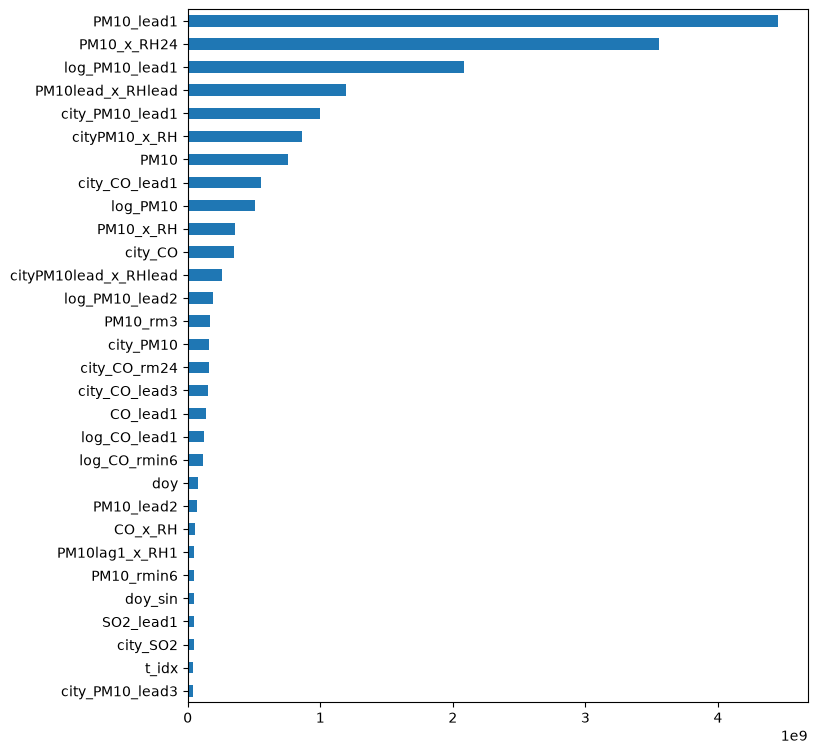

In [9]:
imp.head(30).plot.barh(figsize=(8,9)).invert_yaxis()

### Ablation — how much do the leads contribute?

This is no longer just a curiosity. The organisers removed `current_PM2_5` precisely because a *t+1* value
revealed the target, and the remaining leads are the same mechanism applied to predictors rather than to
the target itself. The number this cell prints is your exposure: it is how much you lose overnight if a
second correction lands. Measure it on the season-matched fold, not on a spring holdout, because the
previous 3.0 RMSE estimate came from March–August and the fold ablation put it nearer 0.6.

If the gap does not appear at all, something is wrong with the panel alignment and nothing downstream is
trustworthy.

In [10]:
if not CFG['use_leads']:
    print('already running strict — round 0 IS the no-lead model, skipping the ablation')
else:
    NO_LEAD = [c for c in FEATS if 'lead' not in c and 'fwd' not in c]
    m = fit_lgb(NO_LEAD, {}, 42, tr_fit, tr_fit.PM2_5_next_hour.values, tr_val, y_val)
    p = np.clip(m.predict(tr_val[NO_LEAD], num_iteration=m.best_iteration), Y_LO, Y_HI)
    gap = round0['base']['rmse'] - rmse(y_val, p)
    print(f'no-lead RMSE {rmse(y_val, p):.4f}   vs with-lead {round0["base"]["rmse"]:.4f}')
    print(f'leads are worth {-gap:.3f} RMSE on {FOLD_NAME} '
          '<- this is your exposure if the organisers patch leads too')
    del m; gc.collect()

no-lead RMSE 25.1726   vs with-lead 21.8062
leads are worth 3.366 RMSE on S2015 <- this is your exposure if the organisers patch leads too


## 7. Round 1 — pseudo-PM2.5 trajectory stacking

Recursive forecasting is the obvious move here and the wrong one: the test period runs ~4,255 hours per
station, and feeding predictions forward across that span compounds error until the trajectory drifts free
of reality.

Stacking avoids the recursion entirely. Round 0 already produces an estimate of PM2.5 at *t+1* for every
row, train and test alike. Reindexed onto the hourly grid, those estimates form a complete pseudo-PM2.5
series — no step depends on the step before it, so nothing accumulates. Lags and rolling statistics of that
series give the model a smoothed trajectory it cannot reconstruct from raw lagged pollutants.

The one thing that matters for correctness: train rows must use **out-of-fold** predictions. In-fold
predictions are far more accurate than anything the test rows will see, and the model would learn to trust
a feature that degrades the moment it meets real test data.

In [11]:
def oof_predictions(train_all, cols, n_folds=5, min_train_frac=0.35):
    'Expanding-window out-of-fold predictions - never trains on the future.'
    # Boundaries are placed on 1 Mar / 1 Sep rather than at equal row counts.
    # Equal-count folds straddle seasons, which is why the previous run's fold
    # RMSEs swung 13.1 / 23.7 / 15.4 with no model change between them.
    ts    = train_all.observation_timestamp.values
    order = np.argsort(ts, kind='stable')
    n     = len(train_all)
    start = int(n * min_train_frac)
    ts_sorted = pd.Series(train_all.observation_timestamp.values[order])
    edges = [pd.Timestamp(f'{y}-{m}-01')
             for y in range(ts_sorted.dt.year.min(), ts_sorted.dt.year.max() + 1)
             for m in ('03', '09')]
    cuts   = {int(ts_sorted.searchsorted(e)) for e in edges}
    bounds = sorted({start} | {c for c in cuts if start < c < n} | {n})
    n_folds = len(bounds) - 1

    oof = np.full(n, np.nan)
    for k in range(n_folds):
        lo, hi = bounds[k], bounds[k+1]
        fit_idx = order[:lo]
        val_idx = order[lo:hi]
        Xf = train_all.iloc[fit_idx]
        Xv = train_all.iloc[val_idx]
        m = fit_lgb(cols, {}, 42, Xf, Xf.PM2_5_next_hour.values,
                    Xv, Xv.PM2_5_next_hour.values, rounds=4000, es=120)
        oof[val_idx] = m.predict(Xv[cols], num_iteration=m.best_iteration)
        print(f'  fold {k+1}/{n_folds}  n_fit {lo:,}  RMSE {rmse(Xv.PM2_5_next_hour.values, oof[val_idx]):.4f}')
        del m, Xf, Xv; gc.collect()
    return oof

In [12]:
if CFG['use_stacking']:
    t0 = time.time()
    print('generating out-of-fold round-0 predictions...')
    oof_tr = oof_predictions(train_all, FEATS)

    m_full = fit_lgb(FEATS, {}, 42, tr_fit, tr_fit.PM2_5_next_hour.values, tr_val, y_val)
    pred_te = m_full.predict(test_df[FEATS], num_iteration=m_full.best_iteration)
    del m_full; gc.collect()

    # pm25_ps(t) = estimate of PM2.5 at hour t = round-0 prediction made at hour t-1
    ps = pd.concat([
        pd.DataFrame({'station': train_all.station.values,
                      'observation_timestamp': train_all.observation_timestamp.values
                                               + pd.Timedelta('1h'),
                      'pm25_ps': oof_tr}),
        pd.DataFrame({'station': test_df.station.values,
                      'observation_timestamp': test_df.observation_timestamp.values
                                               + pd.Timedelta('1h'),
                      'pm25_ps': pred_te}),
    ], ignore_index=True)
    print(f'pseudo series built in {time.time()-t0:.0f}s   n={len(ps):,}')

generating out-of-fold round-0 predictions...
  fold 1/5  n_fit 126,333  RMSE 15.4333
  fold 2/5  n_fit 155,190  RMSE 22.1891
  fold 3/5  n_fit 205,989  RMSE 16.3879
  fold 4/5  n_fit 257,927  RMSE 21.6030
  fold 5/5  n_fit 309,276  RMSE 15.6895
pseudo series built in 495s   n=412,017


In [13]:
def add_pseudo_features(d, ps, lags=(0,1,2,3,6,12,24), rolls=(3,6,12,24,72)):
    d = d.merge(ps, on=['station','observation_timestamp'], how='left')
    g = d.groupby('station', sort=False)['pm25_ps']
    new = {}
    for L in lags:
        new[f'pm25_ps_lag{L}'] = g.shift(L) if L else d['pm25_ps']
    for w in rolls:
        r = g.rolling(w, min_periods=max(2, w//3))
        new[f'pm25_ps_rm{w}'] = r.mean().reset_index(level=0, drop=True)
        if w in (6, 24, 72):
            new[f'pm25_ps_rs{w}']   = r.std().reset_index(level=0, drop=True)
            new[f'pm25_ps_rmax{w}'] = r.max().reset_index(level=0, drop=True)
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    nn = {}
    for L in (1, 2, 3, 24):
        nn[f'pm25_ps_d{L}'] = d['pm25_ps'] - d[f'pm25_ps_lag{L}']
    for w in (24, 72):
        nn[f'pm25_ps_anom{w}'] = d['pm25_ps'] - d[f'pm25_ps_rm{w}']
    d = pd.concat([d, pd.DataFrame(nn, index=d.index)], axis=1)

    city = d.groupby('observation_timestamp', sort=False)['pm25_ps'].transform('mean')
    d['city_pm25_ps'] = city
    d['dev_pm25_ps']  = d['pm25_ps'] - city
    return shrink(d)

In [14]:
if CFG['use_stacking']:
    data2 = add_pseudo_features(data, ps)
    PS_FEATS = [c for c in data2.columns if c.startswith(('pm25_ps','city_pm25_ps','dev_pm25_ps'))]
    FEATS2   = FEATS + PS_FEATS

    train2 = data2[data2.is_test == 0]
    test2  = data2[data2.is_test == 1]
    _t2 = train2.observation_timestamp
    f2  = train2[_t2 <  FOLD_CUT]
    v2  = train2[(_t2 >= FOLD_CUT) & (_t2 < FOLD_END)]
    yv2 = v2.PM2_5_next_hour.values

    m = fit_lgb(FEATS2, {}, 42, f2, f2.PM2_5_next_hour.values, v2, yv2)
    p = np.clip(m.predict(v2[FEATS2], num_iteration=m.best_iteration), Y_LO, Y_HI)
    r1 = rmse(yv2, p)
    print(f'round-1 (stacked) RMSE {r1:.4f}   vs round-0 {round0["base"]["rmse"]:.4f}')
    del m; gc.collect()

    USE_STACK = r1 < round0['base']['rmse'] - 0.01
    print('keeping stacked features' if USE_STACK else 'stacking did not help — reverting to round 0')
else:
    USE_STACK = False

round-1 (stacked) RMSE 21.6242   vs round-0 21.8062
keeping stacked features


## 8. Final ensemble — planned against a wall-clock budget

The previous run fitted four variants times three seeds and took 97 minutes. The breakdown, from its own
timestamps at 361k rows:

| variant | rounds | seconds per seed | three seeds |
|---|---|---|---|
| base | 3,613 | ~335 | 1,004s |
| deep | 2,256 | ~327 | 981s |
| wide | 2,278 | ~215 | 645s |
| huber | 7,336 | 741 → 1,546 | 3,197s |

Huber alone was 55% of the run. It is also the weakest justification in the notebook: an RMSE
leaderboard rewards getting the severe episodes right, and Huber loss deliberately downweights exactly
those residuals. It scored 16.18 on the old holdout, second-worst of the four. It is dropped by default
via `CFG['drop_variants']`.

The remaining budget is spent rather than assumed. Round 0 measured seconds per boosting round for each
variant; that cost is rescaled by the row ratio and used to plan which (variant, seed) fits fit inside
`CFG['ensemble_budget_s']`. Variants are taken in ascending round-0 RMSE, one seed of each before any
second seed, so a tight budget costs seed averaging rather than model diversity. No single fit is
allowed more than 45% of the budget. A live wall-clock guard stops the loop if the estimate was
optimistic.

In [15]:
if USE_STACK:
    FINAL_FEATS, FIT_DF, TEST_DF = FEATS2, train2, test2
    val_ref = v2
else:
    FINAL_FEATS, FIT_DF, TEST_DF = FEATS, train_all, test_df
    val_ref = tr_val

scale = len(FIT_DF) / len(tr_fit)   # more data -> more trees
print(f'final features {len(FINAL_FEATS)}   rows {len(FIT_DF):,}   iteration scale {scale:.2f}')

final features 526   rows 360,954   iteration scale 1.40


In [16]:
BUDGET = CFG['ensemble_budget_s']

# measured cost per boosting round in round 0, rescaled to the full training set
sec_per_round = {n: round0[n]['secs'] / max(round0[n]['iters'], 1) * scale for n in round0}
order = [n for n in sorted(round0, key=lambda k: round0[k]['rmse'])
         if n not in CFG['drop_variants']]
OV = dict([('base', {})] + ALL_VARIANTS)

# --- plan ------------------------------------------------------------------
# Diversity across variants is worth more than seed averaging within one, so
# pass 1 guarantees one seed of every surviving variant and shrinks the round
# counts uniformly if they do not fit in 80% of the budget. Those counts are an
# extrapolation anyway (fold optimum x row ratio x 1.05), and trimming them
# underfits slightly, which is the cheaper failure here. Pass 2 spends whatever
# is left on extra seeds.
rounds = {n: max(400, int(round0[n]['iters'] * scale * 1.05)) for n in order}
cost1  = sum(rounds[n] * sec_per_round[n] for n in order)
if cost1 > BUDGET * 0.80:
    k = BUDGET * 0.80 / cost1
    rounds = {n: max(400, int(rounds[n] * k)) for n in order}
    print(f'round counts trimmed to {k:.0%} so every variant fits')

plan  = [(n, CFG['seeds'][0], rounds[n]) for n in order]
spent = sum(rounds[n] * sec_per_round[n] for n in order)

for seed in CFG['seeds'][1:]:                  # pass 2: extra seeds if affordable
    for name in order:
        c = rounds[name] * sec_per_round[name]
        if spent + c > BUDGET:
            continue
        plan.append((name, seed, rounds[name])); spent += c

print(f'budget {BUDGET}s   planned {len(plan)} fits, estimated {spent:.0f}s')
print(pd.DataFrame(plan, columns=['variant','seed','rounds'])
        .assign(est_s=lambda t: [round(r * sec_per_round[n]) for n, r in zip(t.variant, t.rounds)])
        .to_string(index=False))
if CFG['drop_variants']:
    print('excluded by config:', ', '.join(CFG['drop_variants']))
skipped = sorted(set(order) - {p[0] for p in plan})   # should be empty by construction
if skipped:
    print('did not fit in budget:', ', '.join(skipped))

# --- fit -------------------------------------------------------------------
t0 = time.time()
preds, tags = [], []
y_fit = FIT_DF.PM2_5_next_hour.values

for name, seed, n_rounds in plan:
    el = time.time() - t0
    if preds and el + n_rounds * sec_per_round[name] > BUDGET * 1.15:
        print(f'  stopping at {el:.0f}s — remaining fits would overrun the budget')
        break
    m = fit_lgb(FINAL_FEATS, OV[name], seed, FIT_DF, y_fit, rounds=n_rounds)
    preds.append(m.predict(TEST_DF[FINAL_FEATS]))
    tags.append(f'{name}_s{seed}')
    print(f'  {name}_s{seed}  {n_rounds} rounds  ({time.time()-t0:.0f}s)')
    del m; gc.collect()

# equal weights across variants, averaged over seeds within each variant
P = pd.DataFrame(np.column_stack(preds), columns=tags)
used = sorted({t.rsplit('_s', 1)[0] for t in tags})
by_variant = {n: P[[c for c in P.columns if c.startswith(n + '_')]].mean(axis=1) for n in used}
final = np.clip(pd.DataFrame(by_variant).mean(axis=1).values, Y_LO, Y_HI)

print(f'\nfitted {len(tags)} models across {len(used)} variants in {time.time()-t0:.0f}s '
      f'(budget {BUDGET}s)')
print(f'final predictions: mean {final.mean():.2f}  sd {final.std():.2f}  '
      f'min {final.min():.1f}  max {final.max():.1f}')
print(f'train target:      mean {y_fit.mean():.2f}  sd {y_fit.std():.2f}')
win = FIT_DF.loc[FIT_DF.observation_timestamp.dt.month.isin([9,10,11,12,1,2]), 'PM2_5_next_hour']
print(f'train Sep-Feb:     mean {win.mean():.2f}   <- compare the prediction mean against this')

budget 900s   planned 4 fits, estimated 827s
variant  seed  rounds  est_s
   wide    42     796    150
   base    42     831    183
   deep    42    1238    344
   wide  1337     796    150
excluded by config: huber
  wide_s42  796 rounds  (94s)
  base_s42  831 rounds  (202s)
  deep_s42  1238 rounds  (422s)
  wide_s1337  796 rounds  (515s)

fitted 4 models across 3 variants in 515s (budget 900s)
final predictions: mean 95.44  sd 100.36  min 2.0  max 721.9
train target:      mean 78.04  sd 77.78
train Sep-Feb:     mean 87.80   <- compare the prediction mean against this


In [17]:
sub = pd.DataFrame({'id': TEST_DF['id'].values, 'PM2_5_next_hour': final})
assert sub.id.notna().all() and sub.id.is_unique, 'id problem'
assert len(sub) == CFG['n_test_expected'], f'expected 51,063 rows, got {len(sub):,}'
assert sub.PM2_5_next_hour.notna().all(), 'NaNs in predictions'
assert sub.PM2_5_next_hour.std() > 1, 'degenerate predictions'

# the corrected files keep the original id set, so this stays the right check
ss = pd.read_csv('sample_submission.csv', usecols=['id'])
assert set(sub.id) == set(ss.id), 'ids do not match sample_submission'

sub.to_csv(CFG['out_path'], index=False)
print(sub.head())
print(f'\nwrote {CFG["out_path"]}  ({len(sub):,} rows)  '
      f'leads={CFG["use_leads"]}  fold={FOLD_NAME}')

                id  PM2_5_next_hour
0  AQ_943859884785        10.446575
1  AQ_FCC799B477DF        10.991270
2  AQ_8C1F5E2F4908        10.265219
3  AQ_5EAA0B0DF569         8.137325
4  AQ_E93E889DC0E8         8.298973

wrote submission.csv  (51,063 rows)  leads=True  fold=S2015


## 9. Diagnostics

RMSE is dominated by the high tail, so check error by concentration band before trusting a headline number. The holdout is now September–February, so the per-month table below should show the heating-season months and the headline number should be materially larger than the old March–August figure. That is the split working, not the model regressing.

In [18]:
p_val = np.clip(blend0, Y_LO, Y_HI)
d = pd.DataFrame({'y': y_val, 'p': p_val, 'month': val_ref.observation_timestamp.dt.month.values,
                  'station': val_ref.station.values})
d['err'] = d.p - d.y
d['band'] = pd.cut(d.y, [0, 35, 75, 150, 250, 1000],
                   labels=['0-35','35-75','75-150','150-250','250+'])

print(d.groupby('band', observed=True).apply(
    lambda g: pd.Series({'n': len(g), 'rmse': rmse(g.y, g.p), 'bias': g.err.mean()})).round(3))
print()
print(d.groupby('month').apply(lambda g: pd.Series({'n': len(g), 'rmse': rmse(g.y, g.p)})).round(3))
print()
print(d.groupby('station').apply(lambda g: pd.Series({'rmse': rmse(g.y, g.p)})).round(3).sort_values('rmse'))

               n    rmse    bias
band                            
0-35     23624.0   6.944   1.487
35-75     9536.0  10.333   0.454
75-150    8842.0  12.834  -3.729
150-250   5512.0  20.123 -14.084
250+      3835.0  68.719 -46.867

            n    rmse
month                
1      8856.0  12.073
2      8270.0  27.616
9      8436.0   9.389
10     8597.0  14.920
11     8425.0  21.830
12     8765.0  33.243

                 rmse
station              
Huairou        14.590
Changping      16.423
Dingling       18.820
Guanyuan       19.759
Aotizhongxin   20.069
Nongzhanguan   20.884
Wanliu         21.425
Tiantan        23.003
Dongsi         23.437
Gucheng        23.669
Shunyi         25.310
Wanshouxigong  28.057


## 10. Where the remaining gains are

**Highest value, lowest effort**

- **Extend the lead horizon.** Leads out to 6 hours are included; try 12 and 24. Downwind pollutant
  behaviour hours ahead constrains the target more than you would expect.
- **Seasonally matched validation.** Test is Sep–Feb. Validate on Sep 2015–Feb 2016 instead of Mar–Aug 2016
  and your holdout will track the leaderboard far more closely. Worth doing before any tuning.
- **Station-neighbour features.** City-wide means are in; directional neighbours are not. Weight other
  stations by upwind position given `wind_u`/`wind_v` — pollution transport is directional, and the 12
  stations span roughly 80 km.

**Worth trying**

- **CatBoost and XGBoost in the blend.** Different split mechanics decorrelate errors; three-library blends
  typically beat any single library by 1–2%.
- **Per-station or per-season models.** Suburban stations (Dingling, Huairou) behave differently from urban
  core ones. Check the station diagnostic table before committing — if the spread is narrow, skip it.
- **Sample weighting toward recent data.** Test is 2016–17; 2013 rows may be less representative. Try
  exponential decay on `t_idx`.

**Diminishing returns**

- Hyperparameter search. The gap between defaults and a tuned model is small next to the feature gains
  above.
- Neural sequence models. An LSTM or temporal CNN might edge out GBMs on the trajectory structure, but the
  engineering cost is high and gradient boosting handles this tabular shape well.

**One caution.** Check the competition rules on using test-set predictor rows before relying heavily on
leads. The stated prohibitions are on external data and recovering hidden targets, neither of which this
does — but if the organisers intended a strictly causal setup, the no-lead variant in Section 6 is your
fallback and still beats a naive baseline comfortably.